In [153]:
import json
import torch
import numpy as np
import pandas as pd
from datasets import Dataset
from evaluate import load
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from transformers import (
    BertTokenizerFast,
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    TrainingArguments,
    Trainer,
    pipeline
)


In [2]:
with open("../data/labeled_data.json", "r", encoding="utf-8") as f:
    data = json.load(f)
data[0]


{'text': 'vou pagar semana que vem pode ser?',
 'id': 1,
 'entities': [{'start': 4, 'end': 9, 'text': 'pagar', 'labels': ['PAGAMENTO']},
  {'start': 10, 'end': 24, 'text': 'semana que vem', 'labels': ['TEMPO']}],
 'orientacao': [{'start': 4,
   'end': 9,
   'text': 'pagar',
   'labels': ['positiva']},
  {'start': 10, 'end': 24, 'text': 'semana que vem', 'labels': ['positiva']}],
 'modalidade': [{'start': 4,
   'end': 9,
   'text': 'pagar',
   'labels': ['condicional']},
  {'start': 10,
   'end': 24,
   'text': 'semana que vem',
   'labels': ['condicional']}],
 'referencia_temporal': [{'start': 4,
   'end': 9,
   'text': 'pagar',
   'labels': ['futuro']},
  {'start': 10, 'end': 24, 'text': 'semana que vem', 'labels': ['futuro']}],
 'annotator': 1,
 'annotation_id': 1,
 'created_at': '2025-05-28T20:40:45.167886Z',
 'updated_at': '2025-05-28T20:40:45.167886Z',
 'lead_time': 89.45599999999999}

In [3]:
data[0]


{'text': 'vou pagar semana que vem pode ser?',
 'id': 1,
 'entities': [{'start': 4, 'end': 9, 'text': 'pagar', 'labels': ['PAGAMENTO']},
  {'start': 10, 'end': 24, 'text': 'semana que vem', 'labels': ['TEMPO']}],
 'orientacao': [{'start': 4,
   'end': 9,
   'text': 'pagar',
   'labels': ['positiva']},
  {'start': 10, 'end': 24, 'text': 'semana que vem', 'labels': ['positiva']}],
 'modalidade': [{'start': 4,
   'end': 9,
   'text': 'pagar',
   'labels': ['condicional']},
  {'start': 10,
   'end': 24,
   'text': 'semana que vem',
   'labels': ['condicional']}],
 'referencia_temporal': [{'start': 4,
   'end': 9,
   'text': 'pagar',
   'labels': ['futuro']},
  {'start': 10, 'end': 24, 'text': 'semana que vem', 'labels': ['futuro']}],
 'annotator': 1,
 'annotation_id': 1,
 'created_at': '2025-05-28T20:40:45.167886Z',
 'updated_at': '2025-05-28T20:40:45.167886Z',
 'lead_time': 89.45599999999999}

In [4]:
records = []
for item in data:
    try:
        for i, ent in enumerate(item["entities"]):
            records.append({
                "text":                        item["text"],
                "start":                       ent["start"],
                "end":                         ent["end"],
                "entity_label":                ent["labels"][0],
                "referencia_temporal_label":   item["referencia_temporal"][i]["labels"][0],
                "modalidade_label":            item["modalidade"][i]["labels"][0],
                "orientacao_label":            item["orientacao"][i]["labels"][0],
            })
    except Exception as e:
        print(f"Error: {e}, {item}")
len(records)


704

In [5]:
records[0]


{'text': 'vou pagar semana que vem pode ser?',
 'start': 4,
 'end': 9,
 'entity_label': 'PAGAMENTO',
 'referencia_temporal_label': 'futuro',
 'modalidade_label': 'condicional',
 'orientacao_label': 'positiva'}

In [6]:
df = pd.DataFrame(records)
df.head()


,text,start,end,entity_label,referencia_temporal_label,modalidade_label,orientacao_label
0,vou pagar semana que vem pode ser?,4,9,PAGAMENTO,futuro,condicional,positiva
1,vou pagar semana que vem pode ser?,10,24,TEMPO,futuro,condicional,positiva
2,infelizmente não vou conseguir pagar sexta,31,36,PAGAMENTO,futuro,negado,negativa
3,infelizmente não vou conseguir pagar sexta,37,42,TEMPO,futuro,negado,negativa
4,preciso de prazo até quando receber meu salário,11,16,CONDIÇÃO,futuro,condicional,positiva


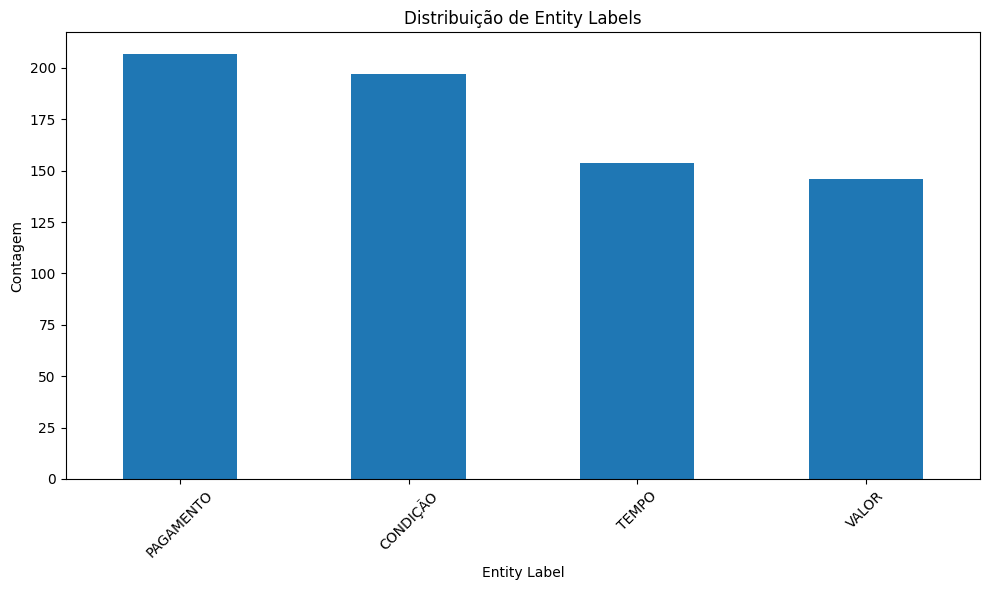

In [7]:
plt.figure(figsize=(10,6))
df['entity_label'].value_counts().plot(kind='bar')
plt.title('Distribuição de Entity Labels')
plt.xlabel('Entity Label')
plt.ylabel('Contagem')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [8]:
df_entity = df[['text', 'start', 'end', 'entity_label']]
df_entity.head()


,text,start,end,entity_label
0,vou pagar semana que vem pode ser?,4,9,PAGAMENTO
1,vou pagar semana que vem pode ser?,10,24,TEMPO
2,infelizmente não vou conseguir pagar sexta,31,36,PAGAMENTO
3,infelizmente não vou conseguir pagar sexta,37,42,TEMPO
4,preciso de prazo até quando receber meu salário,11,16,CONDIÇÃO


In [9]:
def to_iob_tags(group):
    text = group.name
    labels = ["O"] * len(text)
    for _, row in group.iterrows():
        for i in range(row.start, row.end):
            prefix = "B-" if i == row.start else "I-"
            labels[i] = prefix + row.entity_label
    return pd.DataFrame({"text": text, "tags": [labels]})


In [10]:
iob_df = (
    df_entity
    .groupby("text", sort=False)
    .apply(to_iob_tags)
    .reset_index(drop=True)
)
iob_df.head()


C:\Users\mathe\AppData\Local\Temp\ipykernel_27112\1260785468.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(to_iob_tags)


,text,tags
0,vou pagar semana que vem pode ser?,"[O, O, O, O, B-PAGAMENTO, I-PAGAMENTO, I-PAGAM..."
1,infelizmente não vou conseguir pagar sexta,"[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ..."
2,preciso de prazo até quando receber meu salário,"[O, O, O, O, O, O, O, O, O, O, O, B-CONDIÇÃO, ..."
3,até fim do dia eu pago certinho,"[O, O, O, O, B-TEMPO, I-TEMPO, I-TEMPO, I-TEMP..."
4,ainda hoje sem falta,"[O, O, O, O, O, O, B-TEMPO, I-TEMPO, I-TEMPO, ..."


In [11]:
iob_df["words"] = iob_df["text"].str.split()

def chars_to_word_tags(text, char_tags):
    words = text.split()
    tags = []
    idx = 0
    for w in words:
        chunk = char_tags[idx : idx + len(w)]
        tag = next((t for t in chunk if t != "O"), "O")
        tags.append(tag)
        idx += len(w) + 1
    return tags

iob_df["word_tags"] = iob_df.apply(
    lambda row: chars_to_word_tags(row["text"], row["tags"]), axis=1
)


In [12]:
iob_df.head()


,text,tags,words,word_tags
0,vou pagar semana que vem pode ser?,"[O, O, O, O, B-PAGAMENTO, I-PAGAMENTO, I-PAGAM...","[vou, pagar, semana, que, vem, pode, ser?]","[O, B-PAGAMENTO, B-TEMPO, I-TEMPO, I-TEMPO, O, O]"
1,infelizmente não vou conseguir pagar sexta,"[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...","[infelizmente, não, vou, conseguir, pagar, sexta]","[O, O, O, O, B-PAGAMENTO, B-TEMPO]"
2,preciso de prazo até quando receber meu salário,"[O, O, O, O, O, O, O, O, O, O, O, B-CONDIÇÃO, ...","[preciso, de, prazo, até, quando, receber, meu...","[O, O, B-CONDIÇÃO, O, O, B-CONDIÇÃO, I-CONDIÇÃ..."
3,até fim do dia eu pago certinho,"[O, O, O, O, B-TEMPO, I-TEMPO, I-TEMPO, I-TEMP...","[até, fim, do, dia, eu, pago, certinho]","[O, B-TEMPO, I-TEMPO, I-TEMPO, O, B-PAGAMENTO, O]"
4,ainda hoje sem falta,"[O, O, O, O, O, O, B-TEMPO, I-TEMPO, I-TEMPO, ...","[ainda, hoje, sem, falta]","[O, B-TEMPO, O, O]"


In [13]:
iob_df.describe()


,text,tags,words,word_tags
count,281,281,281,281
unique,281,271,281,228
top,vou pagar semana que vem pode ser?,"[O, O, O, O, O, O, O, O, O, B-VALOR, I-VALOR, ...","[vou, pagar, semana, que, vem, pode, ser?]","[O, O, B-VALOR]"
freq,1,3,1,5


In [14]:
letters = [x for x in iob_df.iloc[0].text]
labels  = [x for x in iob_df.iloc[0].tags]

for letter, label in zip(letters, labels):
    print(f"{letter} | {label}")


v | O
o | O
u | O
  | O
p | B-PAGAMENTO
a | I-PAGAMENTO
g | I-PAGAMENTO
a | I-PAGAMENTO
r | I-PAGAMENTO
  | O
s | B-TEMPO
e | I-TEMPO
m | I-TEMPO
a | I-TEMPO
n | I-TEMPO
a | I-TEMPO
  | I-TEMPO
q | I-TEMPO
u | I-TEMPO
e | I-TEMPO
  | I-TEMPO
v | I-TEMPO
e | I-TEMPO
m | I-TEMPO
  | O
p | O
o | O
d | O
e | O
  | O
s | O
e | O
r | O
? | O


In [15]:
iob_df = iob_df.drop(columns=["text", "tags"])


In [16]:
for i in range(10):
    letters = [x for x in iob_df.iloc[i].words]
    labels  = [x for x in iob_df.iloc[i].word_tags]

    for letter, label in zip(letters, labels):
        print(f"{letter:12} | {label}")
    print(f'{"="*30}')


vou          | O
pagar        | B-PAGAMENTO
semana       | B-TEMPO
que          | I-TEMPO
vem          | I-TEMPO
pode         | O
ser?         | O
infelizmente | O
não          | O
vou          | O
conseguir    | O
pagar        | B-PAGAMENTO
sexta        | B-TEMPO
preciso      | O
de           | O
prazo        | B-CONDIÇÃO
até          | O
quando       | O
receber      | B-CONDIÇÃO
meu          | I-CONDIÇÃO
salário      | I-CONDIÇÃO
até          | O
fim          | B-TEMPO
do           | I-TEMPO
dia          | I-TEMPO
eu           | O
pago         | B-PAGAMENTO
certinho     | O
ainda        | O
hoje         | B-TEMPO
sem          | O
falta        | O
aceita       | B-PAGAMENTO
905,15       | B-VALOR
pra          | O
quitar       | B-CONDIÇÃO
tudo?        | I-CONDIÇÃO
ese          | B-TEMPO
mês          | I-TEMPO
estourou     | B-CONDIÇÃO
o            | I-CONDIÇÃO
orçamento    | I-CONDIÇÃO
preciso      | O
de           | O
mais         | B-CONDIÇÃO
prazo,       | I-CONDIÇÃO
to           

In [17]:
train_df = iob_df.sample(frac=0.8, random_state=42)
eval_df  = iob_df.drop(train_df.index)

len(train_df),len(eval_df)


(225, 56)

In [18]:
train_ds = Dataset.from_pandas(train_df)
eval_ds  = Dataset.from_pandas(eval_df)

len(train_df),len(eval_df)


(225, 56)

In [19]:
checkpoint = "neuralmind/bert-base-portuguese-cased"
tokenizer = BertTokenizerFast.from_pretrained(checkpoint)


In [20]:
unique_tags = []
for tag_list in iob_df["word_tags"]:
    for tag in tag_list:
        if tag not in unique_tags:
            unique_tags.append(tag)
unique_tags


['O',
 'B-PAGAMENTO',
 'B-TEMPO',
 'I-TEMPO',
 'B-CONDIÇÃO',
 'I-CONDIÇÃO',
 'B-VALOR',
 'I-VALOR',
 'I-PAGAMENTO']

In [21]:
tag2id = {tag: idx for idx, tag in enumerate(unique_tags)}
id2tag = {idx: tag for tag, idx in tag2id.items()}

tag2id, id2tag


({'O': 0,
  'B-PAGAMENTO': 1,
  'B-TEMPO': 2,
  'I-TEMPO': 3,
  'B-CONDIÇÃO': 4,
  'I-CONDIÇÃO': 5,
  'B-VALOR': 6,
  'I-VALOR': 7,
  'I-PAGAMENTO': 8},
 {0: 'O',
  1: 'B-PAGAMENTO',
  2: 'B-TEMPO',
  3: 'I-TEMPO',
  4: 'B-CONDIÇÃO',
  5: 'I-CONDIÇÃO',
  6: 'B-VALOR',
  7: 'I-VALOR',
  8: 'I-PAGAMENTO'})

In [22]:
def encode_and_align_labels_word(examples):
    tokenized = tokenizer(
        examples["words"],
        is_split_into_words=True,
        truncation=True,
        padding="max_length",
        max_length=128,
    )
    all_labels = []
    for batch_idx in range(len(tokenized["input_ids"])):
        word_ids = tokenized.word_ids(batch_index=batch_idx)
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            else:
                tag = examples["word_tags"][batch_idx][word_idx]
                # primeiro sub-token → mantém B-*, sub-tokens seguintes → converte B-* em I-*
                if word_idx != previous_word_idx:
                    label_id = tag2id[tag]
                else:
                    if tag.startswith("B-"):
                        tag = "I-" + tag.split("-", 1)[1]
                    label_id = tag2id[tag]
                label_ids.append(label_id)
            previous_word_idx = word_idx
        all_labels.append(label_ids)
    tokenized["labels"] = all_labels
    return tokenized


In [23]:
train_encodings = train_ds.map(
    encode_and_align_labels_word,
    batched=True,
    remove_columns=["words", "word_tags"]
)
eval_encodings = eval_ds.map(
    encode_and_align_labels_word,
    batched=True,
    remove_columns=["words", "word_tags"]
)

train_encodings.features


Map: 100%|██████████| 56/56 [00:00<00:00, 4260.96 examples/s]


{'__index_level_0__': Value(dtype='int64', id=None),
 'input_ids': Sequence(feature=Value(dtype='int32', id=None), length=-1, id=None),
 'token_type_ids': Sequence(feature=Value(dtype='int8', id=None), length=-1, id=None),
 'attention_mask': Sequence(feature=Value(dtype='int8', id=None), length=-1, id=None),
 'labels': Sequence(feature=Value(dtype='int64', id=None), length=-1, id=None)}

In [24]:
frase = train_encodings[0]
for input_ids, labels, attention_mask in zip(frase['input_ids'], frase['labels'], frase['attention_mask']):
    if attention_mask == 1:
        print(f"input_ids: {input_ids:12} | label id: {labels:12} | equivalente: {id2tag[labels] if labels != -100 else '[PAD]':12} | attention_mask: {attention_mask:10}")



input_ids:          101 | label id:         -100 | equivalente: [PAD]        | attention_mask:          1
input_ids:          761 | label id:            0 | equivalente: O            | attention_mask:          1
input_ids:          176 | label id:            4 | equivalente: B-CONDIÇÃO   | attention_mask:          1
input_ids:         2779 | label id:            5 | equivalente: I-CONDIÇÃO   | attention_mask:          1
input_ids:        18424 | label id:            5 | equivalente: I-CONDIÇÃO   | attention_mask:          1
input_ids:          146 | label id:            5 | equivalente: I-CONDIÇÃO   | attention_mask:          1
input_ids:         3495 | label id:            5 | equivalente: I-CONDIÇÃO   | attention_mask:          1
input_ids:          117 | label id:            5 | equivalente: I-CONDIÇÃO   | attention_mask:          1
input_ids:          395 | label id:            0 | equivalente: O            | attention_mask:          1
input_ids:          521 | label id:           

In [25]:
exemplo = train_encodings[0]
tokens = tokenizer.convert_ids_to_tokens(exemplo['input_ids'])
labels = exemplo['labels']

print("Alinhamento token-label:")
print("-" * 30)
for token, label in zip(tokens, labels):
    if label != -100:
        print(f"{token:20} | {id2tag[label]}")

from collections import Counter
labels_validas = [l for l in labels if l != -100]
dist_labels = Counter(id2tag[l] for l in labels_validas)

print("\nDistribuição das labels:")
print("-" * 30)
for label, count in dist_labels.items():
    print(f"{label:20} | {count:}")


Alinhamento token-label:
------------------------------
Com                  | O
se                   | B-CONDIÇÃO
eu                   | I-CONDIÇÃO
tiver                | I-CONDIÇÃO
o                    | I-CONDIÇÃO
dinheiro             | I-CONDIÇÃO
,                    | I-CONDIÇÃO
fa                   | O
##ço                 | O
o                    | O
pagamento            | B-PAGAMENTO
de                   | O
setenta              | B-VALOR
e                    | I-VALOR
sete                 | I-VALOR
reais                | I-VALOR
em                   | O
15                   | B-TEMPO
dias                 | I-TEMPO

Distribuição das labels:
------------------------------
O                    | 6
B-CONDIÇÃO           | 1
I-CONDIÇÃO           | 5
B-PAGAMENTO          | 1
B-VALOR              | 1
I-VALOR              | 3
B-TEMPO              | 1
I-TEMPO              | 1


In [26]:
model = AutoModelForTokenClassification.from_pretrained(
    checkpoint,
    num_labels=len(unique_tags),  
    id2label=id2tag,        
    label2id=tag2id    
)


Some weights of BertForTokenClassification were not initialized from the model checkpoint at neuralmind/bert-base-portuguese-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [27]:
data_collator = DataCollatorForTokenClassification(tokenizer)


In [48]:

training_args = TrainingArguments(
    output_dir="./bert-ner",
    do_train=True,
    do_eval=True,
    eval_strategy="epoch",   
    logging_strategy="steps",   
    save_strategy="steps",    
    eval_steps=200,             
    logging_steps=50,           
    save_steps=200,             
    per_device_train_batch_size=36,
    per_device_eval_batch_size=36,
    num_train_epochs=6,
    learning_rate=3e-5,
    weight_decay=0.01,
    no_cuda=False,
    use_cpu=False,
)


In [50]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_encodings,
    eval_dataset=eval_encodings,
    tokenizer=tokenizer,
    data_collator=data_collator,
)


C:\Users\mathe\AppData\Local\Temp\ipykernel_27112\2257340954.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [51]:
trainer.train()


Epoch,Training Loss,Validation Loss
1,No log,0.665182
2,No log,0.589989
3,No log,0.549028
4,No log,0.530945
5,No log,0.522480
6,No log,0.520106


TrainOutput(global_step=42, training_loss=0.5140785489763532, metrics={'train_runtime': 14.9195, 'train_samples_per_second': 90.486, 'train_steps_per_second': 2.815, 'total_flos': 88193236492800.0, 'train_loss': 0.5140785489763532, 'epoch': 6.0})

In [52]:
metrics = trainer.evaluate()
metrics



{'eval_loss': 0.5201064944267273,
 'eval_runtime': 0.338,
 'eval_samples_per_second': 165.662,
 'eval_steps_per_second': 5.916,
 'epoch': 6.0}

In [53]:
metric = load("seqeval")


In [54]:
def strip_prefix(tag):
    return tag if tag == "O" else tag.split("-", 1)[1]

def align_predictions(predictions, label_ids):
    preds = np.argmax(predictions, axis=2)
    batch_size, seq_len = preds.shape

    true_labels = []
    true_preds  = []
    for i in range(batch_size):
        curr_preds  = []
        curr_labels = []
        for j in range(seq_len):
            if label_ids[i, j] != -100:
                pred_tag = id2tag[preds[i, j]]
                true_tag = id2tag[label_ids[i, j]]
                curr_preds.append(strip_prefix(pred_tag))
                curr_labels.append(strip_prefix(true_tag))
        true_preds.append(curr_preds)
        true_labels.append(curr_labels)
    return true_preds, true_labels


In [55]:
predictions, label_ids, _ = trainer.predict(eval_encodings)



In [56]:
true_preds, true_labels = align_predictions(predictions, label_ids)


In [57]:
for i in range(5):
    print("SENTENÇA:", ' '.join(eval_ds[i]["words"]))
    print("Word         | True         | Pred")
    print("_"*40)
    for word, true, pred in zip(eval_ds[i]["words"], true_labels[i], true_preds[i]):
        print(f"{word}{(12-len(word))*' '} | {true}{(12-len(true))*' '} | {pred}")
    print(f'{"="*40}')
    print(f'')
    
    


SENTENÇA: preciso de mais prazo, to sem condições
Word         | True         | Pred
________________________________________
preciso      | O            | O
de           | O            | O
mais         | CONDIÇÃO     | CONDIÇÃO
prazo,       | CONDIÇÃO     | CONDIÇÃO
to           | CONDIÇÃO     | CONDIÇÃO
sem          | O            | O
condições    | CONDIÇÃO     | O

SENTENÇA: não dá pra quitar com desconto?
Word         | True         | Pred
________________________________________
não          | O            | O
dá           | O            | O
pra          | O            | O
quitar       | PAGAMENTO    | CONDIÇÃO
com          | PAGAMENTO    | CONDIÇÃO
desconto?    | O            | CONDIÇÃO

SENTENÇA: Se em 10 pracelas, eu pago cento e vinte reais no dia 1
Word         | True         | Pred
________________________________________
Se           | O            | O
em           | O            | O
10           | CONDIÇÃO     | VALOR
pracelas,    | CONDIÇÃO     | VALOR
eu           | CON

In [58]:
results = metric.compute(predictions=true_preds, references=true_labels)

print({k: v for k, v in results.items() if k.endswith("f1")})
print({k: v for k, v in results.items() if k.endswith("precision")})
print({k: v for k, v in results.items() if k.endswith("recall")})


{'overall_f1': 0.7661016949152541}
{'overall_precision': 0.7533333333333333}
{'overall_recall': 0.7793103448275862}


c:\Users\mathe\repos\study\POLI\NLP\t1\.venv\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: CONDIÇÃO seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
c:\Users\mathe\repos\study\POLI\NLP\t1\.venv\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: PAGAMENTO seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
c:\Users\mathe\repos\study\POLI\NLP\t1\.venv\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: VALOR seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
c:\Users\mathe\repos\study\POLI\NLP\t1\.venv\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: TEMPO seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))


In [59]:
ner = pipeline(
    "token-classification",
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy="simple"
)


Device set to use cuda:0


In [136]:
frase = "eu nao vou conseguir pagar esse mes, mas consigo pagar no proximo se tiver algum desconto"

result = ner(frase)
for ent in result:
    print(f"{ent['word']:30} → {ent['entity_group']:30} score: {ent['score']:.2f}") 


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


conseguir pagar                → PAGAMENTO                      score: 0.60
esse mes,                      → TEMPO                          score: 0.85
consigo pagar                  → PAGAMENTO                      score: 0.62
proximo                        → TEMPO                          score: 0.90
se tiver algum desconto        → CONDIÇÃO                       score: 0.80


In [69]:
ds = Dataset.from_pandas(df)
ds[0]


{'text': 'vou pagar semana que vem pode ser?',
 'start': 4,
 'end': 9,
 'entity_label': 'PAGAMENTO',
 'referencia_temporal_label': 'futuro',
 'modalidade_label': 'condicional',
 'orientacao_label': 'positiva'}

In [70]:
def encode_and_extract_spans(examples):
    tokenized = tokenizer(
        examples["text"],
        return_offsets_mapping=True,
        truncation=True,
        padding="max_length",
        max_length=128,
    )
    span_token_indices = []
    for i, offsets in enumerate(tokenized["offset_mapping"]):
        s, e = examples["start"][i], examples["end"][i]
        idxs = [j for j, (st, en) in enumerate(offsets) if not (en <= s or st >= e)]
        span_token_indices.append(idxs)
    tokenized["span_token_indices"] = span_token_indices
    tokenized.pop("offset_mapping")
    return tokenized

ds_enc = ds.map(encode_and_extract_spans, batched=True)


Map: 100%|██████████| 704/704 [00:00<00:00, 8019.40 examples/s]


In [71]:
ds_enc[0]['text']


'vou pagar semana que vem pode ser?'

In [72]:
for input_ids, attention_mask in zip(ds_enc[0]['input_ids'], ds_enc[0]['attention_mask']):
    if attention_mask == 1:
        print(f"input_ids: {input_ids:10} |  attention_mask: {attention_mask:10}")


input_ids:        101 |  attention_mask:          1
input_ids:      17891 |  attention_mask:          1
input_ids:       7198 |  attention_mask:          1
input_ids:       2767 |  attention_mask:          1
input_ids:        179 |  attention_mask:          1
input_ids:       3539 |  attention_mask:          1
input_ids:        706 |  attention_mask:          1
input_ids:        333 |  attention_mask:          1
input_ids:        136 |  attention_mask:          1
input_ids:        102 |  attention_mask:          1


In [73]:
ent_labels = ds_enc["entity_label"]

ohe = OneHotEncoder(sparse_output=False).fit(
    [[lbl] for lbl in ent_labels]
)

onehots = ohe.transform([[lbl] for lbl in ent_labels]).tolist()

ds_enc = ds_enc.add_column(
    "entity_onehot",
    onehots
)


In [74]:
print(ds_enc.column_names)
print(ds_enc[0]["entity_onehot"])


['text', 'start', 'end', 'entity_label', 'referencia_temporal_label', 'modalidade_label', 'orientacao_label', 'input_ids', 'token_type_ids', 'attention_mask', 'span_token_indices', 'entity_onehot']
[0.0, 1.0, 0.0, 0.0]


In [76]:
target_cols = [
    "referencia_temporal_label",
    "modalidade_label",
    "orientacao_label",
]
encoders = {}
for col in target_cols:
    le = LabelEncoder().fit(ds_enc[col])
    encoders[col] = le
    ds_enc = ds_enc.add_column(
        f"{col}_id",
        le.transform(ds_enc[col]).tolist()
    )


In [79]:
ds_enc.column_names, ds_enc[0]['orientacao_label_id']


(['text',
  'start',
  'end',
  'entity_label',
  'referencia_temporal_label',
  'modalidade_label',
  'orientacao_label',
  'input_ids',
  'token_type_ids',
  'attention_mask',
  'span_token_indices',
  'entity_onehot',
  'referencia_temporal_label_id',
  'modalidade_label_id',
  'orientacao_label_id'],
 2)

In [94]:
def extract_entity_features(bert_model, input_ids, attention_mask, span_indices, entity_onehot):
    device = next(bert_model.parameters()).device
    with torch.no_grad():
        outputs = bert_model(
            input_ids=torch.tensor(input_ids).unsqueeze(0).to(device),
            attention_mask=torch.tensor(attention_mask).unsqueeze(0).to(device),
            
        )
        hidden_states = outputs.last_hidden_state[0]  # [seq_len, 768]
    
    # 1. EMBEDDING DA FRASE TODA (token CLS)
    sentence_embedding = hidden_states[0]  # [768] - token [CLS]
    
    # 2. EMBEDDING DA ENTIDADE ESPECÍFICA  
    if len(span_indices) > 0:
        entity_embedding = hidden_states[span_indices].mean(dim=0)  # [768]
    else:
        entity_embedding = torch.zeros(768, device=device)
    
    # 3. CONTEXTO LOCAL (tokens ao redor da entidade)
    context_start = max(0, span_indices[0] - 2)
    context_end = min(len(hidden_states), span_indices[0] + 3)
    context_embedding = hidden_states[context_start:context_end].mean(dim=0)  # [768]
    
    # 4. TIPO DA ENTIDADE
    entity_type = torch.tensor(entity_onehot, dtype=torch.float32, device=device)  # [4]
    
    # 5. CONCATENAR TUDO
    features = torch.cat([
        sentence_embedding,   # 768 - contexto global
        entity_embedding,     # 768 - entidade específica  
        context_embedding,    # 768 - contexto local
        entity_type          # 4   - tipo da entidade
    ])  # Total: 768 + 768 + 768 + 4 = 2308 dimensões
    
    return features


In [98]:
features = extract_entity_features(
    model.bert,
    ds_enc[0]['input_ids'],
    ds_enc[0]['attention_mask'], 
    ds_enc[0]['span_token_indices'],
    ds_enc[0]['entity_onehot']
)
features.shape, features[:5]


(torch.Size([2308]),
 tensor([-0.5748, -0.7167,  0.4306,  0.3560,  0.4656], device='cuda:0'))

In [99]:
def process_example(example):
    features = extract_entity_features(
        model.bert,
        example['input_ids'],
        example['attention_mask'], 
        example['span_token_indices'],
        example['entity_onehot']
    )
    
    return {
        'features': features.cpu().numpy(),
        'labels': [
            example['referencia_temporal_label_id'],
            example['modalidade_label_id'],
            example['orientacao_label_id']
        ]
    }


In [101]:
ds_features = ds_enc.map(process_example, desc="Extraindo features")


Extraindo features: 100%|██████████| 704/704 [00:08<00:00, 87.19 examples/s]


In [103]:
def expand_features_and_labels(example):
    feature_dict = {f'feature_{i}': example['features'][i] for i in range(len(example['features']))}
    
    label_dict = {
        'referencia_temporal': example['labels'][0],
        'modalidade': example['labels'][1], 
        'orientacao': example['labels'][2]
    }
    return {**feature_dict, **label_dict}


In [117]:
ds = ds_features.map(expand_features_and_labels)


Map: 100%|██████████| 704/704 [00:03<00:00, 207.54 examples/s]


In [118]:
len(ds.column_names)


2328

In [119]:
ds = ds.remove_columns(['text',
                        'start',
                        'end',
                        'entity_label',
                        'referencia_temporal_label',
                        'modalidade_label',
                        'orientacao_label',
                        'input_ids',
                        'token_type_ids',
                        'attention_mask',
                        'span_token_indices',
                        'entity_onehot',
                        'referencia_temporal_label_id',
                        'modalidade_label_id',
                        'orientacao_label_id',
                        'features',
                        'labels',])


In [120]:
len(ds.column_names)


2311

In [121]:
label_columns = ds.column_names[-3:]

X = ds.remove_columns(label_columns)
y = ds.select_columns(label_columns)

X.shape, y.shape


((704, 2308), (704, 3))

In [138]:
X_array = np.array(X.to_pandas())
y_array = np.array(y.to_pandas())

X_array[0][0]


-0.5747700929641724

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_array)

pca = PCA(n_components=0.95, ) 
X_reduced = pca.fit_transform(X_scaled)

print(f"Dimensões originais: {X.shape[1]}") 
print(f"Dimensões reduzidas: {X_reduced.shape[1]}")
print(f"Variância explicada: {pca.explained_variance_ratio_.sum():.2f}")


Dimensões originais: 2308
Dimensões reduzidas: 153
Variância explicada: 0.950


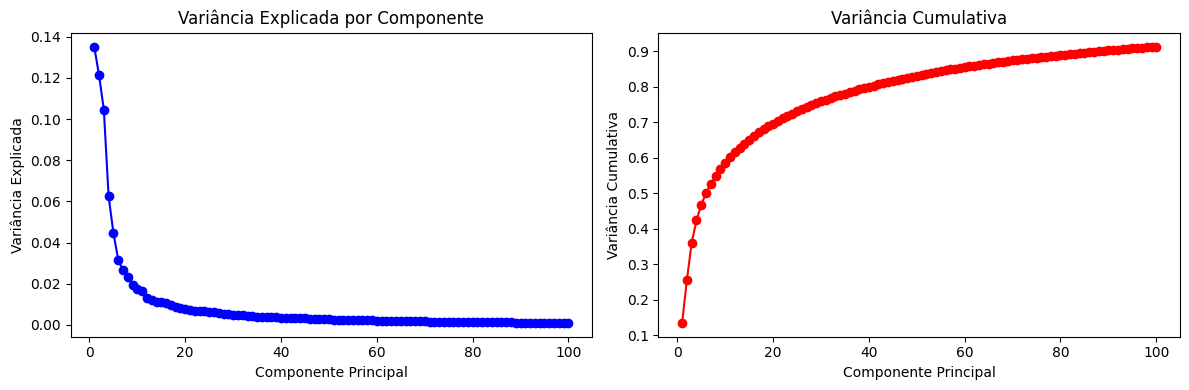

In [167]:


# Explicação da variância por componente
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, 101), pca.explained_variance_ratio_[:100], 'bo-')
plt.title('Variância Explicada por Componente')
plt.xlabel('Componente Principal')
plt.ylabel('Variância Explicada')

plt.subplot(1, 2, 2)
plt.plot(range(1, 101), pca.explained_variance_ratio_[:100].cumsum(), 'ro-')
plt.title('Variância Cumulativa')
plt.xlabel('Componente Principal')
plt.ylabel('Variância Cumulativa')
plt.tight_layout()
plt.show()


In [ ]:
X_reduced


In [130]:
X_reduced.shape, y_array.shape


((704, 153), (704, 3))

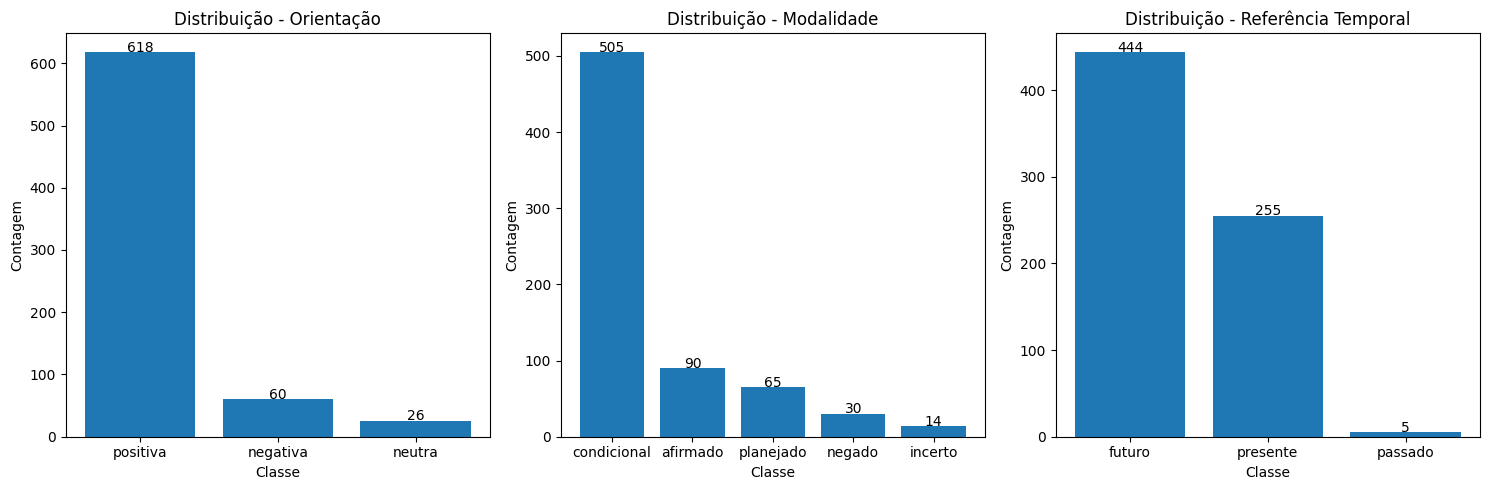

In [80]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Orientação
orientacao_counts = pd.Series(ds_enc['orientacao_label']).value_counts()
axes[0].bar(orientacao_counts.index, orientacao_counts.values)
axes[0].set_title('Distribuição - Orientação')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Contagem')
for i, v in enumerate(orientacao_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center')

# Modalidade  
modalidade_counts = pd.Series(ds_enc['modalidade_label']).value_counts()
axes[1].bar(modalidade_counts.index, modalidade_counts.values)
axes[1].set_title('Distribuição - Modalidade')
axes[1].set_xlabel('Classe')
axes[1].set_ylabel('Contagem')
for i, v in enumerate(modalidade_counts.values):
    axes[1].text(i, v + 0.5, str(v), ha='center')

# Referência Temporal
temporal_counts = pd.Series(ds_enc['referencia_temporal_label']).value_counts()
axes[2].bar(temporal_counts.index, temporal_counts.values)
axes[2].set_title('Distribuição - Referência Temporal')
axes[2].set_xlabel('Classe')
axes[2].set_ylabel('Contagem')
for i, v in enumerate(temporal_counts.values):
    axes[2].text(i, v + 0.5, str(v), ha='center')

plt.tight_layout()
plt.show()


In [139]:
def calculate_class_weights(y_array):
    weights_dict = {}
    
    for i, label_name in enumerate(['referencia_temporal', 'modalidade', 'orientacao']):
        classes = np.unique(y_array[:, i])
        weights = compute_class_weight(
            class_weight='balanced',
            classes=classes,
            y=y_array[:, i]
        )
        weights_dict[label_name] = dict(zip(classes, weights))
        
        unique, counts = np.unique(y_array[:, i], return_counts=True)
        print(f"\n{label_name}:")
        for cls, count, weight in zip(unique, counts, weights):
            print(f"  Classe {cls}: {count:3} amostras → peso {weight:.3f}")
    
    return weights_dict


In [140]:
class_weights = calculate_class_weights(y_array)
class_weights



referencia_temporal:
  Classe 0: 444 amostras → peso 0.529
  Classe 1:   5 amostras → peso 46.933
  Classe 2: 255 amostras → peso 0.920

modalidade:
  Classe 0:  90 amostras → peso 1.564
  Classe 1: 505 amostras → peso 0.279
  Classe 2:  14 amostras → peso 10.057
  Classe 3:  30 amostras → peso 4.693
  Classe 4:  65 amostras → peso 2.166

orientacao:
  Classe 0:  60 amostras → peso 3.911
  Classe 1:  26 amostras → peso 9.026
  Classe 2: 618 amostras → peso 0.380


{'referencia_temporal': {0: 0.5285285285285285,
  1: 46.93333333333333,
  2: 0.9202614379084967},
 'modalidade': {0: 1.5644444444444445,
  1: 0.27881188118811884,
  2: 10.057142857142857,
  3: 4.693333333333333,
  4: 2.166153846153846},
 'orientacao': {0: 3.911111111111111,
  1: 9.025641025641026,
  2: 0.37971952535059333}}

In [146]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y_array, test_size=0.2, random_state=42, #stratify=y_array balancear mais antes de usar
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((563, 153), (141, 153), (563, 3), (141, 3))

In [288]:

classifiers = {
    'referencia_temporal': LogisticRegression(
        max_iter=1000,
        C=0.01,
        class_weight=class_weights['referencia_temporal']
    ),
    'modalidade': LogisticRegression(
        max_iter=1000,
        C=0.01,
        class_weight=class_weights['modalidade'] 
    ),
    'orientacao': LogisticRegression(
        max_iter=1000,
        C=0.01,
        
        class_weight=class_weights['orientacao']
    )
}

predictions = {}
for i, (task_name, clf) in enumerate(classifiers.items()):
    print(f"Treinando {task_name}...")
    clf.fit(X_train, y_train[:, i])
    predictions[task_name] = clf.predict(X_test)


print("\nBASELINE - Logistic Regression COM CLASS WEIGHTS:")
for i, task_name in enumerate(['referencia_temporal', 'modalidade', 'orientacao']):
    print(f"\n{task_name.upper()}:")
    print(classification_report(y_test[:, i], predictions[task_name]))


Treinando referencia_temporal...
Treinando modalidade...
Treinando orientacao...

BASELINE - Logistic Regression COM CLASS WEIGHTS:

REFERENCIA_TEMPORAL:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92        87
           1       0.00      0.00      0.00         1
           2       0.85      0.87      0.86        53

    accuracy                           0.89       141
   macro avg       0.59      0.60      0.59       141
weighted avg       0.89      0.89      0.89       141


MODALIDADE:
              precision    recall  f1-score   support

           0       0.75      0.67      0.71        18
           1       0.95      0.88      0.91       102
           2       1.00      1.00      1.00         6
           3       0.62      1.00      0.77         5
           4       0.44      0.70      0.54        10

    accuracy                           0.85       141
   macro avg       0.75      0.85      0.79       141
weighted avg      

c:\Users\mathe\repos\study\POLI\NLP\t1\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\mathe\repos\study\POLI\NLP\t1\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\mathe\repos\study\POLI\NLP\t1\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()

In [289]:
for task_name, clf in classifiers.items():
    task_idx = ['referencia_temporal', 'modalidade', 'orientacao'].index(task_name)
    
    cv_scores = cross_val_score(
        clf, X_reduced, y_array[:, task_idx], 
        cv=5, scoring='f1_macro'
    )
    
    print(f"\n{task_name.upper()}:")
    print(f"  CV F1-macro: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")



REFERENCIA_TEMPORAL:
  CV F1-macro: 0.832 ± 0.132

MODALIDADE:
  CV F1-macro: 0.751 ± 0.042

ORIENTACAO:
  CV F1-macro: 0.906 ± 0.053


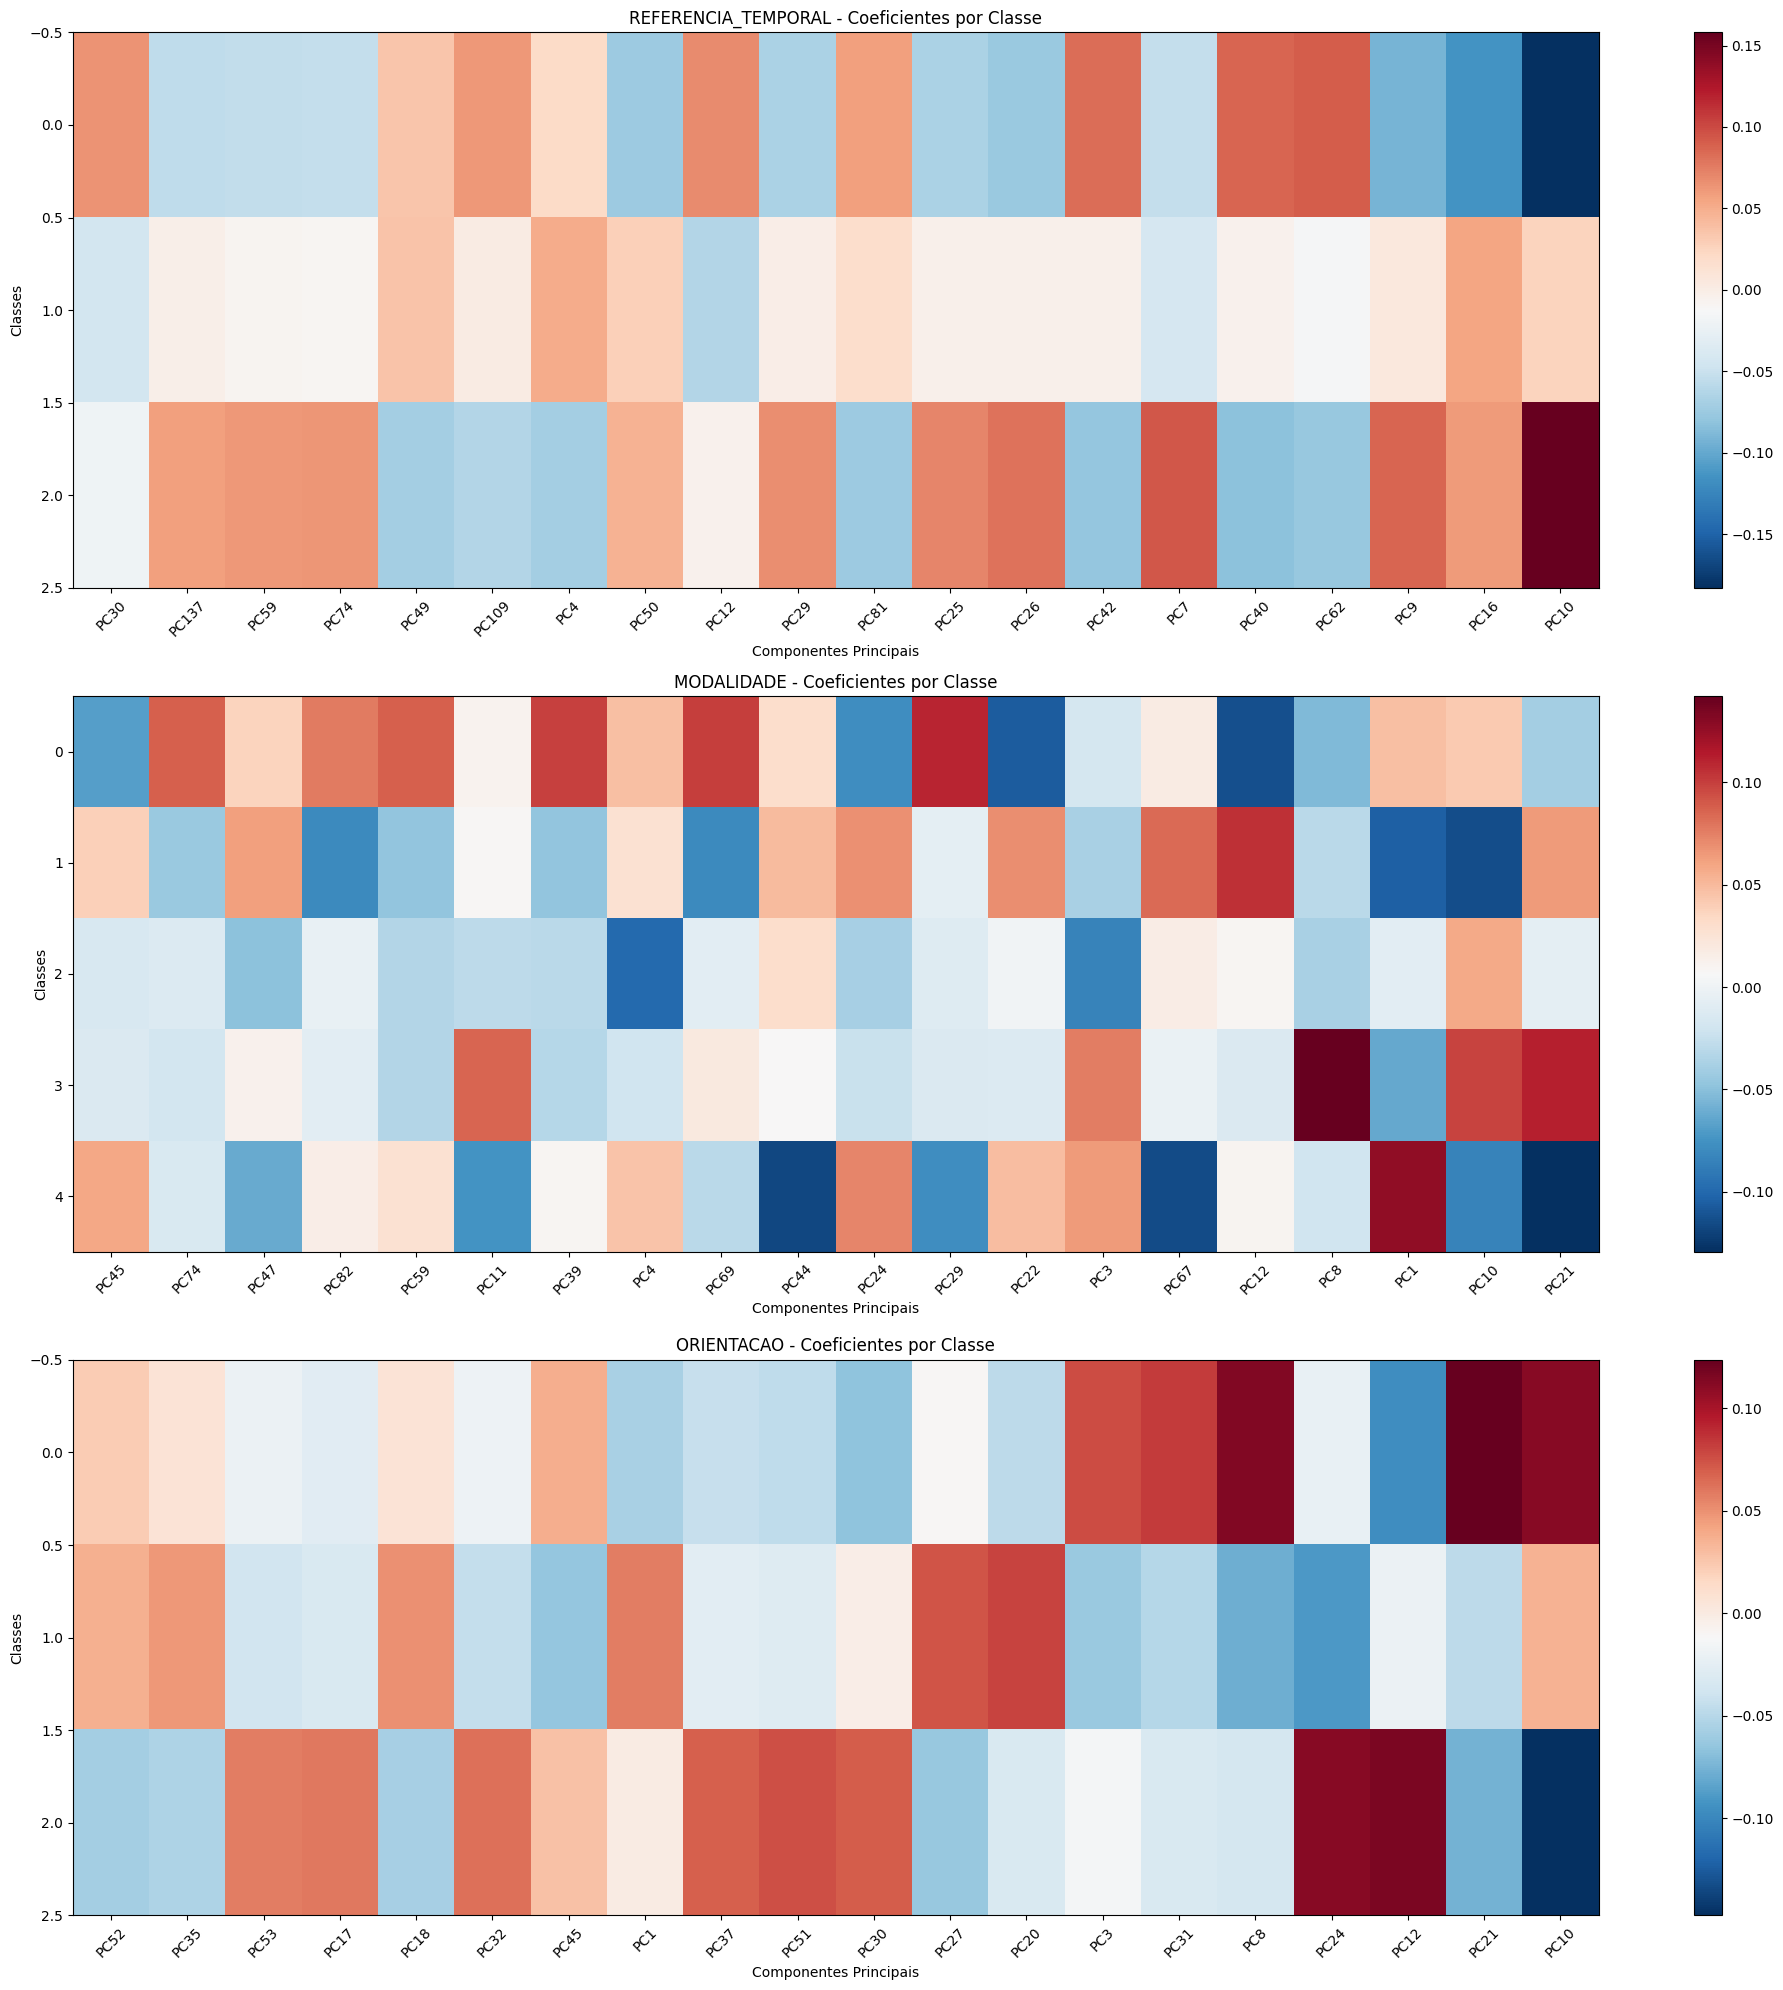

In [290]:
fig, axes = plt.subplots(3, 1, figsize=(20, 20))

for i, (task_name, clf) in enumerate(classifiers.items()):
    feature_importance = np.std(clf.coef_, axis=0) 
    top_indices = np.argsort(feature_importance)[-20:] 

    coef_subset = clf.coef_[:, top_indices]
    im = axes[i].imshow(coef_subset, cmap='RdBu_r', aspect='auto')
    
    axes[i].set_title(f'{task_name.upper()} - Coeficientes por Classe')
    axes[i].set_ylabel('Classes')
    axes[i].set_xlabel('Componentes Principais')
    axes[i].set_xticks(range(20))
    axes[i].set_xticklabels([f'PC{idx+1}' for idx in top_indices], rotation=45)
    
    plt.colorbar(im, ax=axes[i])

plt.tight_layout()
plt.show()


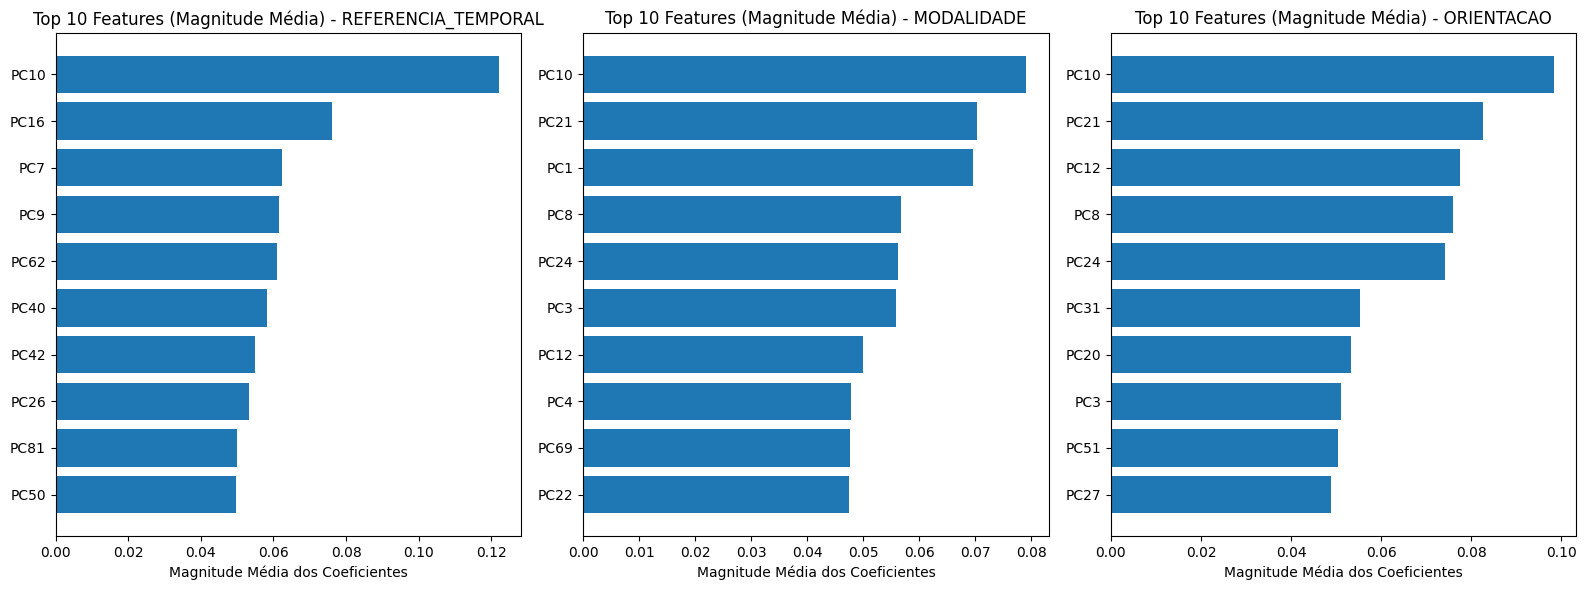

In [291]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for i, (task_name, clf) in enumerate(classifiers.items()):
    # Média da magnitude dos coeficientes entre todas as classes
    coefs_mean = np.mean(np.abs(clf.coef_), axis=0)
    top_indices = np.argsort(coefs_mean)[-10:]
    
    axes[i].barh(range(10), coefs_mean[top_indices])
    axes[i].set_title(f'Top 10 Features (Magnitude Média) - {task_name.upper()}')
    axes[i].set_xlabel('Magnitude Média dos Coeficientes')
    axes[i].set_yticks(range(10))
    axes[i].set_yticklabels([f'PC{idx+1}' for idx in top_indices])

plt.tight_layout()
plt.show()


In [292]:
def entity_type_to_onehot(entity_type, ohe_encoder):
    try:
        onehot = ohe_encoder.transform([[entity_type]])[0].tolist()
        return onehot
    except:
        return [0.0] * len(ohe_encoder.categories_[0])


In [293]:
def predictions_to_labels(predictions, encoders):
    return {
        'referencia_temporal': encoders['referencia_temporal_label'].inverse_transform([predictions['referencia_temporal']])[0],
        'modalidade': encoders['modalidade_label'].inverse_transform([predictions['modalidade']])[0], 
        'orientacao': encoders['orientacao_label'].inverse_transform([predictions['orientacao']])[0]
    }


In [294]:
def pipeline_inf(frase, ner_model, ner_tokenizer, classifiers, pca, scaler, ohe_encoder, label_encoders):
    ner = pipeline("token-classification", model=ner_model, tokenizer=ner_tokenizer, aggregation_strategy="simple")
    entidades = ner(frase)
    
    resultados = []
    
    for ent in entidades:
        examples_batch = {
            "text": [frase], 
            "start": [ent['start']], 
            "end": [ent['end']] 
        }
        
        dados_encoded = encode_and_extract_spans(examples_batch)
        features = extract_entity_features(
            ner_model.bert,
            dados_encoded['input_ids'][0],
            dados_encoded['attention_mask'][0],
            dados_encoded['span_token_indices'][0],
            entity_type_to_onehot(ent['entity_group'], ohe_encoder)
        )
        
        features_scaled = scaler.transform([features.cpu().numpy()])
        features_reduced = pca.transform(features_scaled)
        
        predictions = {}
        scores = {}
        for task_name, clf in classifiers.items():
            predictions[task_name] = clf.predict(features_reduced)[0]
            scores[task_name] = clf.predict_proba(features_reduced)[0]

        labels = predictions_to_labels(predictions, label_encoders)
        
        resultado = {
            'texto': ent['word'],
            'entidade': ent['entity_group'],
            'referencia_temporal': labels['referencia_temporal'],
            'modalidade': labels['modalidade'], 
            'orientacao': labels['orientacao'],
            'score_ner': ent['score'],
            'score': scores
        }
        resultados.append(resultado)
    return resultados 


In [300]:
frase = "nao tenho esse dinheiro pra hoje, mas consigo amanha"

resultados = pipeline_inf(frase, model, tokenizer, classifiers, pca, scaler, ohe, encoders) 
print("RESULTADOS:")
print("-" * 60)
for i, res in enumerate(resultados, 1):
    print(f"{i}. {'**' + res['texto'] + '**':30} -> {res['entidade']:16} (score: {res['score_ner']:.2f})")
    print(f"   Referencia Temporal {'':10} -> {res['referencia_temporal'].upper():16} (score: {max(res['score']['referencia_temporal']):.2f})")
    print(f"   Modalidade {'':19} -> {res['modalidade'].upper():16} (score: {max(res['score']['modalidade']):.2f})")
    print(f"   Orientacao {'':19} -> {res['orientacao'].upper():16} (score: {max(res['score']['orientacao']):.2f})")
    print()
    

Device set to use cuda:0


RESULTADOS:
------------------------------------------------------------
1. **dinheiro**                   -> CONDIÇÃO         (score: 0.78)
   Referencia Temporal            -> PRESENTE         (score: 0.67)
   Modalidade                     -> CONDICIONAL      (score: 0.87)
   Orientacao                     -> NEGATIVA         (score: 1.00)

2. **hoje,**                      -> TEMPO            (score: 0.83)
   Referencia Temporal            -> PRESENTE         (score: 0.94)
   Modalidade                     -> CONDICIONAL      (score: 0.91)
   Orientacao                     -> NEGATIVA         (score: 0.79)

3. **consigo**                    -> PAGAMENTO        (score: 0.75)
   Referencia Temporal            -> FUTURO           (score: 0.83)
   Modalidade                     -> CONDICIONAL      (score: 0.79)
   Orientacao                     -> POSITIVA         (score: 0.52)

4. **amanha**                     -> TEMPO            (score: 0.83)
   Referencia Temporal            -> PRE

In [296]:
for task_name, clf in classifiers.items():
    # Pegar algumas amostras de treino
    sample_features = X_reduced[:10]
    probabilities = clf.predict_proba(sample_features)
    
    print(f"\n{task_name}:")
    print(f"  Min probability: {probabilities.min():.6f}")
    print(f"  Max probability: {probabilities.max():.6f}")
    print(f"  Samples with prob > 0.99: {(probabilities.max(axis=1) > 0.99).sum()}/10")
    print(f"  Samples with prob > 0.999: {(probabilities.max(axis=1) > 0.999).sum()}/10")
    
    # Mostrar algumas probabilidades
    print(f"  First 3 max probabilities: {probabilities.max(axis=1)[:3]}")



referencia_temporal:
  Min probability: 0.000008
  Max probability: 0.998060
  Samples with prob > 0.99: 6/10
  Samples with prob > 0.999: 0/10
  First 3 max probabilities: [0.97369399 0.98963832 0.98885578]

modalidade:
  Min probability: 0.000017
  Max probability: 0.999593
  Samples with prob > 0.99: 2/10
  Samples with prob > 0.999: 2/10
  First 3 max probabilities: [0.97990432 0.98856108 0.98661846]

orientacao:
  Min probability: 0.000021
  Max probability: 0.998448
  Samples with prob > 0.99: 3/10
  Samples with prob > 0.999: 0/10
  First 3 max probabilities: [0.99615602 0.93224005 0.9923697 ]
